<a href="https://colab.research.google.com/github/hamnamuvees1720-oss/northstar-analytics/blob/main/notebooks/03_python_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

All data loaded into Python successfully.
orders: {'booking_channel': np.int64(25)}
deliveries: {'delivery_completed_at': np.int64(19), 'customer_rating_post_delivery': np.int64(14), 'delivery_duration_hrs': np.int64(19)}
complaints: {'compensation_amount': np.int64(16)}
incidents: {'resolved_hours': np.int64(17)}
app_events: {'order_id': np.int64(144)}
hub_id       hub_name      zone  total  failed  on_time  avg_rating  avg_cost  avg_overrides  failure_rate  ontime_rate
   H08  Midtown Relay   Central    128      26       80        3.88     11.71           1.11         20.31        62.50
   H05   Central Core   Central    115      23       67        3.67     13.69           0.95         20.00        58.26
   H06    Airport Hub   Airport    104      15       62        3.88     13.32           0.91         14.42        59.62
   H04      West Gate      West    127      16       83        3.92     13.17           0.87         12.60        65.35
   H01 North Exchange     North    136      

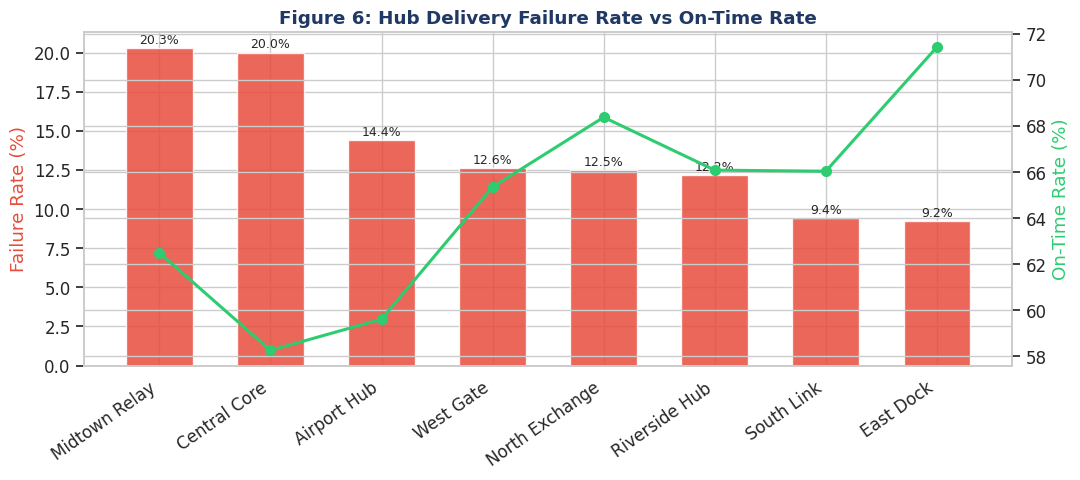

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')

# Setting a clean visual style for your charts
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

BASE = '/content/drive/MyDrive/northstar_data/'

# Load all 9 CSV files into Pandas DataFrames
orders     = pd.read_csv(BASE + 'orders.csv')
deliveries = pd.read_csv(BASE + 'deliveries.csv')
customers  = pd.read_csv(BASE + 'customers.csv')
drivers    = pd.read_csv(BASE + 'drivers.csv')
vehicles   = pd.read_csv(BASE + 'vehicles.csv')
hubs       = pd.read_csv(BASE + 'hubs.csv')
incidents  = pd.read_csv(BASE + 'incidents.csv')
complaints = pd.read_csv(BASE + 'complaints.csv')
app_events = pd.read_csv(BASE + 'app_events.csv')

print("All data loaded into Python successfully.")

# Zone standardisation
def clean_zone(s): return s.str.strip().str.title()
for df,cols in [(orders,['pickup_zone','dropoff_zone']),(customers,['home_zone']),
                (drivers,['base_zone']),(vehicles,['assigned_zone']),
                (app_events,['zone_context'])]:
    for c in cols: df[c] = clean_zone(df[c])

# Datetime parsing
for col in ['dispatch_time','delivery_completed_at']:
    deliveries[col] = pd.to_datetime(deliveries[col], errors='coerce')
orders['order_created_at'] = pd.to_datetime(orders['order_created_at'], errors='coerce')
complaints['created_at']   = pd.to_datetime(complaints['created_at'], errors='coerce')

# Feature engineering
deliveries['delivery_duration_hrs'] = (
    deliveries['delivery_completed_at']-deliveries['dispatch_time']
).dt.total_seconds()/3600
deliveries['is_anomalous'] = deliveries['delivery_duration_hrs'] < 0
deliveries['cost_per_km']  = deliveries['fuel_or_charge_cost'] / deliveries['route_distance_km']
deliveries['is_failed']    = (deliveries['delivery_status']=='Failed').astype(int)

# Missing value report
for name,df in [('orders',orders),('deliveries',deliveries),
                ('complaints',complaints),('incidents',incidents),('app_events',app_events)]:
    m=df.isnull().sum(); m=m[m>0]
    if len(m): print(f'{name}: {dict(m)}')


del_hub = deliveries.merge(hubs, on='hub_id', how='left')
hub_perf = del_hub.groupby(['hub_id','hub_name','zone']).agg(
    total=('delivery_id','count'),
    failed=('delivery_status',lambda x:(x=='Failed').sum()),
    on_time=('delivery_status',lambda x:(x=='OnTime').sum()),
    avg_rating=('customer_rating_post_delivery','mean'),
    avg_cost=('fuel_or_charge_cost','mean'),
    avg_overrides=('manual_route_override_count','mean')
).reset_index()
hub_perf['failure_rate'] = hub_perf['failed']/hub_perf['total']*100
hub_perf['ontime_rate']  = hub_perf['on_time']/hub_perf['total']*100
print(hub_perf.sort_values('failure_rate',ascending=False).round(2).to_string(index=False))

